# Finding Jobs Per Categories

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
from matplotlib import pyplot as plt

salaries = pd.read_csv('data/ds_salaries_clean.csv')
salaries.head()

,Working_Year,Designation,Experience,Employment_Status,Employee_Location,Company_Size,Remote_Working_Ratio,Salary_USD
0,2020,Data Scientist,Mid,FT,DE,L,0,76227.0
1,2020,Machine Learning Scientist,Senior,FT,JP,S,0,248257.0
2,2020,Big Data Engineer,Senior,FT,GB,M,50,104100.0
3,2020,Product Data Analyst,Mid,FT,HN,S,0,19097.0
4,2020,Machine Learning Engineer,Senior,FT,US,L,50,143225.0


In [2]:
job_categories = ["Data Science", "Data Analytics", "Data Engineering", "Machine Learning","Managerial", "Consultant"]

data_science = "Data Scientist|NLP"
data_analyst = "Analyst|Analytics"
data_engineer = "Data Engineer|ETL|Architect|Infrastructure"
ml_engineer = "Machine Learning|ML|Big Data|AI"
manager = "Manager|Head|Director|Lead|Principal|Staff"
consultant = "Consultant|Freelance"

conditions = [    
    (salaries["Designation"].str.contains(data_science)),    
    (salaries["Designation"].str.contains(data_analyst)),    
    (salaries["Designation"].str.contains(data_engineer)),    
    (salaries["Designation"].str.contains(ml_engineer)),    
    (salaries["Designation"].str.contains(manager)),    
    (salaries["Designation"].str.contains(consultant))
    ]

salaries["Job_Category"] = np.select(conditions,                                      
                                     job_categories,                                      
                                     default="Other")

In [3]:
salaries.groupby(['Job_Category','Designation']).agg(counts=("Experience","count"))

counts
Job_Category     Designation                                     
Consultant       Data Science Consultant                        7
Data Analytics   Analytics Engineer                             4
                 BI Data Analyst                                6
                 Business Data Analyst                          5
                 Data Analyst                                  97
                 Data Analytics Engineer                        4
                 Data Analytics Lead                            1
                 Data Analytics Manager                         7
                 Finance Data Analyst                           1
                 Financial Data Analyst                         2
                 Lead Data Analyst                              3
                 Marketing Data Analyst                         1
                 Principal Data Analyst                         2
                 Product Data Analyst                           2
Data Engineering Big Data Architect                             1
                 Big Data Engineer                              8
                 Cloud Data Engineer                            2
                 Data Architect                                11
                 Data Engineer                                132
                 Data Engineering Manager                       5
                 Director of Data Engineering                   2
                 ETL Developer                                  2
                 Lead Data Engineer                             6
                 Machine Learning Infrastructure Engineer       3
                 Principal Data Engineer                        3
Data Science     Applied Data Scientist                         5
                 Data Scientist                               143
                 Lead Data Scientist                            3
                 NLP Engineer                                   1
                 Principal Data Scientist                       7
                 Staff Data Scientist                           1
Machine Learning AI Scientist                                   7
                 Applied Machine Learning Scientist             4
                 Head of Machine Learning                       1
                 Lead Machine Learning Engineer                 1
                 ML Engineer                                    6
                 Machine Learning Developer                     3
                 Machine Learning Engineer                     41
                 Machine Learning Manager                       1
                 Machine Learning Scientist                     8
Managerial       Data Science Manager                          12
                 Director of Data Science                       7
                 Head of Data                                   5
                 Head of Data Science                           4
Other            3D Computer Vision Researcher                  1
                 Computer Vision Engineer                       6
                 Computer Vision Software Engineer              3
                 Data Science Engineer                          3
                 Data Specialist                                1
                 Research Scientist                            16

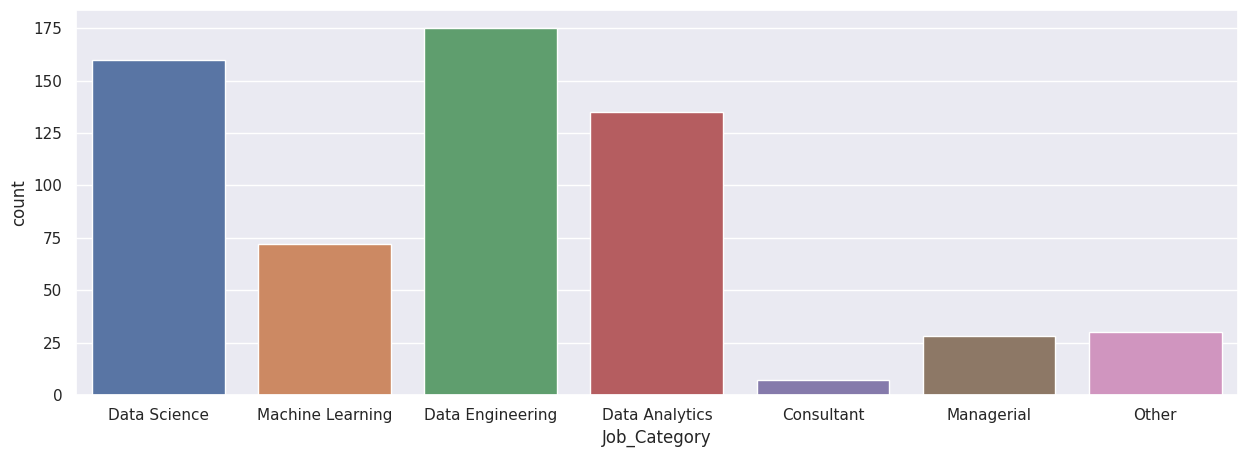

In [5]:
sns.set_theme()
f,ax = plt.subplots(figsize=(15,5))
sns.countplot(data=salaries, x='Job_Category',ax=ax);